# Phase 7C：冻结控制器的多温度 DFN 外推验证

目标：在不重训 ANN、不修改 MPC 或 11.3055225 mV 电压残差增长裕量的条件下，审计 15 ℃与30 ℃ Chen2020 热 DFN。严格停止规则要求安全 MPC 先通过，才允许运行五种子安全 ANN。

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULT = ROOT / 'outputs/phase7c_multitemperature/metrics.json'
TRAJECTORIES = ROOT / 'data/phase7c_multitemperature/closed_loop_trajectories.csv'
payload = json.loads(RESULT.read_text(encoding='utf-8'))
trajectories = pd.read_csv(TRAJECTORIES)
payload['decision']

{'mpc_stage_success': False,
 'ann_stage_completed': False,
 'phase7c_success': False,
 'strict_stop_triggered': True,
 'failed_checks': {'15c': ['zero_solver_failure'],
  '30c': ['maximum_average_temperature', 'zero_oscillation']},
 'conclusion': 'Phase 7C 在安全 MPC 阶段触发严格停止：冻结的25 ℃电压/热安全合同不能直接外推到全部温度；未运行 ANN 扩大实验。'}

## 预注册判据

- 两个温度分别判断，不能平均掩盖失败；
- 最高端电压不超过4.200001 V，最高平均温度不超过35 ℃；
- 电流、斜率、空区间、异常振荡和求解失败均为0；
- 安全 MPC 任一门槛失败时停止，不运行 ANN。

In [2]:
rows = []
for token, result in payload['temperature_results'].items():
    mpc = result['mpc']
    rows.append({
        'temperature_c': result['temperature_c'],
        'maximum_voltage_v': mpc['maximum_voltage_v'],
        'maximum_average_temperature_c': mpc['maximum_average_temperature_c'],
        'maximum_residual_mv': 1000 * mpc['maximum_voltage_residual_v'],
        'maximum_positive_growth_mv': 1000 * mpc['maximum_positive_residual_growth_v'],
        'minimum_voltage_slew_margin_a': mpc['minimum_voltage_slew_feasibility_margin_a'],
        'intervention_percent': 100 * mpc['voltage_intervention_fraction'],
        'failed_checks': ', '.join(k for k, v in result['checks'].items() if not v),
    })
summary = pd.DataFrame(rows)
summary

,temperature_c,maximum_voltage_v,maximum_average_temperature_c,maximum_residual_mv,maximum_positive_growth_mv,minimum_voltage_slew_margin_a,intervention_percent,failed_checks
0,15.0,4.189892,29.104070,35.970382,11.387103,1.88385,44.242958,zero_solver_failure
1,30.0,4.188028,42.263684,5.867547,10.845348,2.00000,0.000000,"maximum_average_temperature, zero_oscillation"


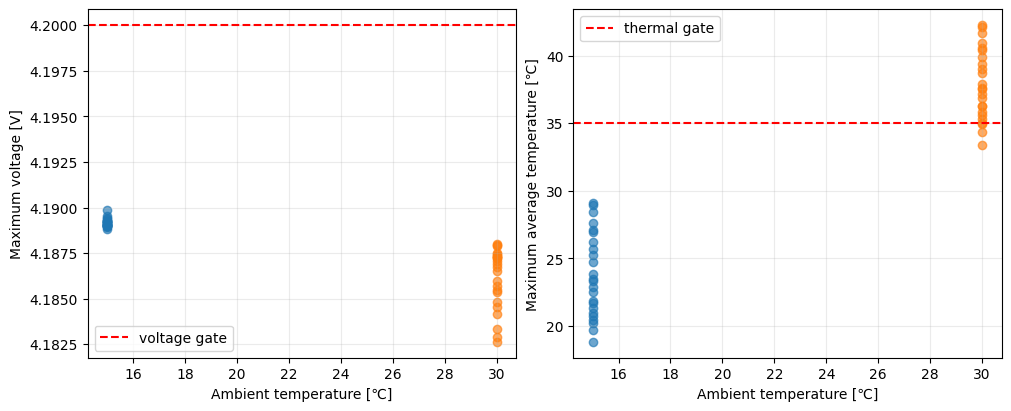

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
for temperature_c, group in trajectories.groupby('temperature_c'):
    maxima = group.groupby('trajectory_id').agg(
        maximum_voltage_v=('terminal_voltage_v', 'max'),
        maximum_average_temperature_c=('average_temperature_c', 'max'),
    )
    axes[0].scatter([temperature_c] * len(maxima), maxima.maximum_voltage_v, alpha=0.65)
    axes[1].scatter([temperature_c] * len(maxima), maxima.maximum_average_temperature_c, alpha=0.65)
axes[0].axhline(4.200001, color='red', linestyle='--', label='voltage gate')
axes[1].axhline(35.0, color='red', linestyle='--', label='thermal gate')
axes[0].set(xlabel='Ambient temperature [℃]', ylabel='Maximum voltage [V]')
axes[1].set(xlabel='Ambient temperature [℃]', ylabel='Maximum average temperature [℃]')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

## 结论与停止决定

Phase 7C 在安全 MPC 阶段停止：30 ℃最高平均温度达到42.264 ℃，说明当前控制架构缺少热约束感知；15 ℃出现一次 MPC 求解状态失败，30 ℃出现一次显著电流方向反转。15 ℃最大残差单步正增长为11.387 mV，略高于冻结的25 ℃裕量。依据预注册合同，不运行 ANN、不调参、不进入扰动或跨电池实验。